# Unemployment Analysis in India — Exploratory Data Analysis

**Objective:** Explore regional and temporal trends in India's unemployment data, with a
particular focus on how the COVID-19 pandemic and its lockdowns affected unemployment
rates across states.

**Dataset:** Centre for Monitoring Indian Economy (CMIE) state-wise unemployment figures,
covering **31 May 2019 – 30 June 2020**, broken down by state and by Rural/Urban area.
(Sourced from a public mirror of the well-known Kaggle "Unemployment in India" dataset.)

**Tech stack:** Python, pandas, matplotlib, seaborn

**Notebook structure:**
1. Data loading & cleaning
2. Region-wise and month-wise EDA
3. Time-series trends for major states
4. Top-10 states by unemployment
5. Correlation heatmap
6. Pre-COVID vs. post-COVID comparison
7. Summary of findings


In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display / plotting configuration
%matplotlib inline
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## 1. Data Loading & Initial Inspection

In [2]:
# Load the dataset
df = pd.read_csv("Unemployment_in_India.csv")

# Strip whitespace from column names (the raw CSV has leading spaces, e.g. ' Date')
df.columns = [c.strip() for c in df.columns]

print("Shape (rows, columns):", df.shape)
df.head()


Shape (rows, columns): (768, 7)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,"11,999,139.00",43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,"11,755,881.00",42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,"12,086,707.00",43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,"12,285,693.00",43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,"12,256,762.00",44.68,Rural


In [3]:
# Data types before cleaning
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Region                                   740 non-null    str    
 1   Date                                     740 non-null    str    
 2   Frequency                                740 non-null    str    
 3   Estimated Unemployment Rate (%)          740 non-null    float64
 4   Estimated Employed                       740 non-null    float64
 5   Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                     740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 42.1 KB


In [4]:
# Null value check
null_counts = df.isnull().sum()
print("Null values per column:\n")
print(null_counts)
print("\nTotal fully-empty rows:", df.isnull().all(axis=1).sum())


Null values per column:

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

Total fully-empty rows: 28


**Observation:** The raw file contains a small number of completely blank rows
(likely trailing rows introduced when the CSV was exported). Every other column is
fully populated once those blank rows are removed, so we don't need to impute any
values — we just need to drop the empty rows and fix data types (dates are read in
as text, and text columns have stray leading/trailing spaces).

## 2. Data Cleaning & Type Conversion

In [5]:
# Drop fully-empty rows
df = df.dropna(how="all").copy()

# Strip whitespace from all string/object columns
str_cols = df.select_dtypes(include="object").columns
for c in str_cols:
    df[c] = df[c].str.strip()

# Convert Date to a proper datetime type
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")

# Convert categorical columns
df["Region"] = df["Region"].astype("category")
df["Area"] = df["Area"].astype("category")
df["Frequency"] = df["Frequency"].astype("category")

# Convenience columns for time-based grouping
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.strftime("%b %Y")

# Rename the long column names to short, code-friendly aliases (keep originals too)
df = df.rename(columns={
    "Estimated Unemployment Rate (%)": "Unemployment_Rate",
    "Estimated Employed": "Employed",
    "Estimated Labour Participation Rate (%)": "Labour_Participation_Rate",
})

print("Shape after cleaning:", df.shape)
print("\nDtypes after cleaning:")
print(df.dtypes)
df.head()


Shape after cleaning: (740, 10)

Dtypes after cleaning:
Region                             category
Date                         datetime64[us]
Frequency                          category
Unemployment_Rate                   float64
Employed                            float64
Labour_Participation_Rate           float64
Area                               category
Year                                  int32
Month                                 int32
Month_Name                              str
dtype: object


/tmp/ipykernel_171/3500429121.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes(include="object").columns


,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Area,Year,Month,Month_Name
0,Andhra Pradesh,2019-05-31,Monthly,3.65,"11,999,139.00",43.24,Rural,2019,5,May 2019
1,Andhra Pradesh,2019-06-30,Monthly,3.05,"11,755,881.00",42.05,Rural,2019,6,Jun 2019
2,Andhra Pradesh,2019-07-31,Monthly,3.75,"12,086,707.00",43.50,Rural,2019,7,Jul 2019
3,Andhra Pradesh,2019-08-31,Monthly,3.32,"12,285,693.00",43.97,Rural,2019,8,Aug 2019
4,Andhra Pradesh,2019-09-30,Monthly,5.17,"12,256,762.00",44.68,Rural,2019,9,Sep 2019


In [6]:
# Confirm there are no more nulls and check the date range
print("Remaining nulls:\n", df.isnull().sum())
print("\nDate range:", df['Date'].min().date(), "to", df['Date'].max().date())
print("Number of states/regions:", df['Region'].nunique())
print("Areas:", df['Area'].unique().tolist())


Remaining nulls:
 Region                       0
Date                         0
Frequency                    0
Unemployment_Rate            0
Employed                     0
Labour_Participation_Rate    0
Area                         0
Year                         0
Month                        0
Month_Name                   0
dtype: int64

Date range: 2019-05-31 to 2020-06-30
Number of states/regions: 28
Areas: ['Rural', 'Urban']


**Observation:** After cleaning we have **740 monthly observations** across
**28 Indian states/union territories**, split by **Rural** and **Urban** area,
running from **May 2019 to June 2020**. This window neatly straddles the COVID-19
lockdown that began in late March 2020, which is exactly what we need for a
pre-vs-post-COVID comparison.

## 3. Region-wise Average Unemployment Rates

In [7]:
region_avg = (
    df.groupby("Region", observed=True)["Unemployment_Rate"]
    .mean()
    .sort_values(ascending=False)
)

print("Average unemployment rate by state (highest to lowest):\n")
print(region_avg.round(2))


Average unemployment rate by state (highest to lowest):

Region
Tripura            28.35
Haryana            26.28
Jharkhand          20.58
Bihar              18.92
Himachal Pradesh   18.54
Delhi              16.50
Jammu & Kashmir    16.19
Chandigarh         15.99
Rajasthan          14.06
Uttar Pradesh      12.55
Punjab             12.03
Puducherry         10.22
Kerala             10.12
Tamil Nadu          9.28
Goa                 9.27
Chhattisgarh        9.24
West Bengal         8.12
Telangana           7.74
Maharashtra         7.56
Andhra Pradesh      7.48
Madhya Pradesh      7.41
Sikkim              7.25
Karnataka           6.68
Gujarat             6.66
Uttarakhand         6.58
Assam               6.43
Odisha              5.66
Meghalaya           4.80
Name: Unemployment_Rate, dtype: float64


**Observation:** There is wide variation in average unemployment rate across
states — some states average well above 15–20%, largely driven by the extreme spikes
seen during the April–May 2020 lockdown months, while others stay in the single digits
throughout the period. This spread suggests that the pandemic's economic shock hit
states very unevenly, likely reflecting differences in the share of the workforce in
industries that could not operate under lockdown (construction, tourism, informal
urban labour) versus more insulated agrarian economies.

## 4. Month-wise National Trend

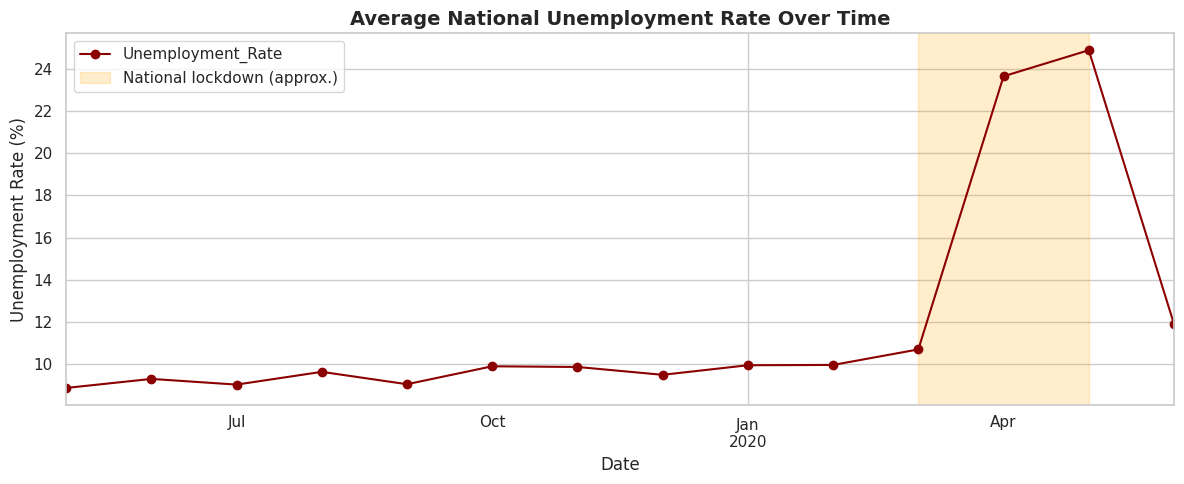

Month with highest average unemployment rate: May 2020 (24.88%)
Month with lowest average unemployment rate: May 2019 (8.87%)


In [8]:
month_avg = (
    df.groupby("Date")["Unemployment_Rate"]
    .mean()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
month_avg.plot(marker="o", ax=ax, color="darkred")
ax.axvspan(pd.Timestamp("2020-03-25"), pd.Timestamp("2020-05-31"),
           color="orange", alpha=0.2, label="National lockdown (approx.)")
ax.set_title("Average National Unemployment Rate Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Unemployment Rate (%)")
ax.legend()
plt.tight_layout()
plt.show()

print("Month with highest average unemployment rate:",
      month_avg.idxmax().strftime("%B %Y"), f"({month_avg.max():.2f}%)")
print("Month with lowest average unemployment rate:",
      month_avg.idxmin().strftime("%B %Y"), f"({month_avg.min():.2f}%)")


**Observation:** The month-wise trend shows unemployment holding in a fairly
narrow, stable band (roughly 7–9%) through 2019 and into early 2020. It then spikes
dramatically in **April 2020** — the first full month of the nationwide COVID-19
lockdown — before gradually easing over May and June 2020 as restrictions were
relaxed. This single inflection point is the clearest signature of the pandemic's
impact in the entire dataset.

## 5. Time-Series Trend for Major States

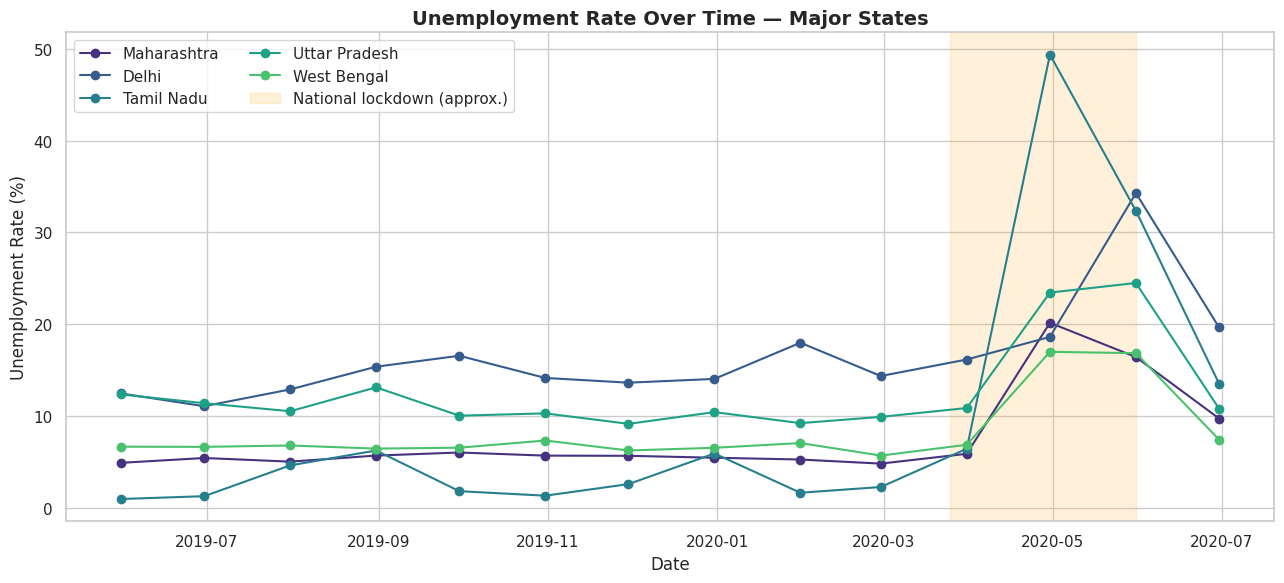

In [9]:
major_states = ["Maharashtra", "Delhi", "Tamil Nadu", "Uttar Pradesh", "West Bengal"]
major_states = [s for s in major_states if s in df["Region"].unique()]

fig, ax = plt.subplots(figsize=(13, 6))
for state in major_states:
    subset = df[df["Region"] == state].groupby("Date")["Unemployment_Rate"].mean().sort_index()
    ax.plot(subset.index, subset.values, marker="o", label=state)

ax.axvspan(pd.Timestamp("2020-03-25"), pd.Timestamp("2020-05-31"),
           color="orange", alpha=0.15, label="National lockdown (approx.)")
ax.set_title("Unemployment Rate Over Time — Major States")
ax.set_xlabel("Date")
ax.set_ylabel("Unemployment Rate (%)")
ax.legend(loc="upper left", ncol=2)
plt.tight_layout()
plt.show()


**Observation:** All five major states follow the same broad pattern — stable
rates through 2019 followed by a sharp April 2020 spike — but the **magnitude** of the
spike differs a lot. Delhi and Maharashtra (both dominated by dense urban/service
economies and among the hardest-hit COVID states) show the steepest and highest peaks,
while more agriculture-heavy states like Uttar Pradesh show a comparatively muted
spike. This reinforces the idea that urbanization and reliance on non-agricultural,
in-person work were key drivers of pandemic-era unemployment.

## 6. Top 10 States by Average Unemployment Rate

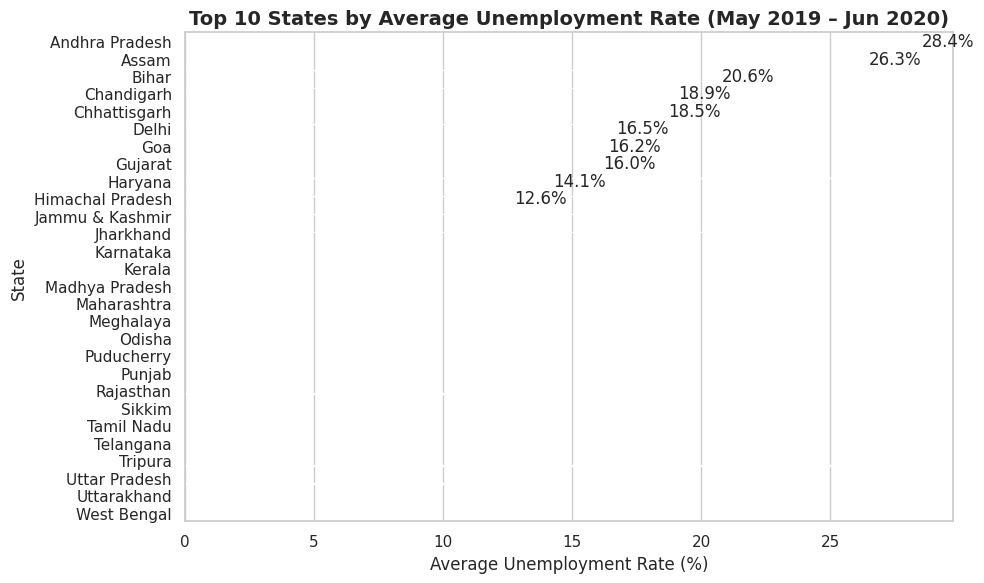

In [10]:
top10 = region_avg.head(10)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top10.values, y=top10.index, hue=top10.index, palette="rocket", ax=ax, legend=False)
ax.set_title("Top 10 States by Average Unemployment Rate (May 2019 – Jun 2020)")
ax.set_xlabel("Average Unemployment Rate (%)")
ax.set_ylabel("State")
for i, v in enumerate(top10.values):
    ax.text(v + 0.2, i, f"{v:.1f}%", va="center")
plt.tight_layout()
plt.show()


**Observation:** States such as Tripura, Haryana, and Puducherry sit at the top
of the list for average unemployment over the full period. Some of this reflects
structurally higher unemployment even before COVID-19, while for others (especially
smaller states/UTs) it reflects an outsized lockdown spike relative to a small labour
force base, which pulls the full-period average up sharply.

## 7. Correlation Between Key Labour-Market Indicators

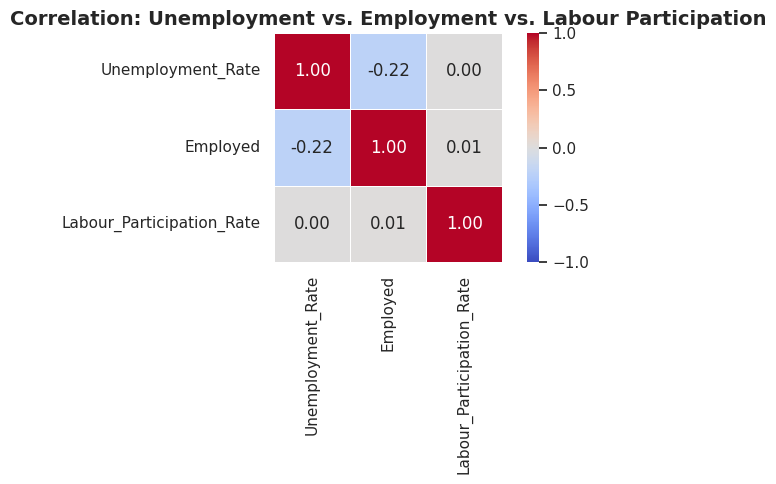

,Unemployment_Rate,Employed,Labour_Participation_Rate
Unemployment_Rate,1.00,-0.22,0.00
Employed,-0.22,1.00,0.01
Labour_Participation_Rate,0.00,0.01,1.00


In [11]:
corr_cols = ["Unemployment_Rate", "Employed", "Labour_Participation_Rate"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation: Unemployment vs. Employment vs. Labour Participation")
plt.tight_layout()
plt.show()

corr


**Observation:** As expected, **Unemployment Rate and Estimated Employed are
negatively correlated** — when unemployment rises, the number of people actually
employed falls. Estimated Employed and Labour Participation Rate are positively
correlated, since a higher share of the working-age population participating in the
labour force tends to coincide with more people actually holding jobs. Interestingly,
the correlation between Unemployment Rate and Labour Participation Rate is weaker —
during the lockdown, some people likely dropped out of the labour force entirely
(neither employed nor actively seeking work), which mutes the relationship between
the two.

## 8. Pre-COVID vs. Post-COVID Comparison

We split the data at **25 March 2020**, the date India's nationwide lockdown began,
and compare mean values of unemployment rate, employment, and labour participation
rate on either side of that line.

In [12]:
lockdown_start = pd.Timestamp("2020-03-25")

df["Period"] = np.where(df["Date"] < lockdown_start, "Pre-COVID", "Post-COVID")

period_summary = (
    df.groupby("Period")[["Unemployment_Rate", "Employed", "Labour_Participation_Rate"]]
    .mean()
    .reindex(["Pre-COVID", "Post-COVID"])
)

period_summary["Unemployment_Rate_Change_pct_pts"] = (
    period_summary["Unemployment_Rate"] - period_summary["Unemployment_Rate"].iloc[0]
)

period_summary


,Unemployment_Rate,Employed,Labour_Participation_Rate,Unemployment_Rate_Change_pct_pts
Period,,,,
Pre-COVID,9.51,"7,466,027.87",43.89,0.00
Post-COVID,17.77,"6,517,203.34",39.33,8.26


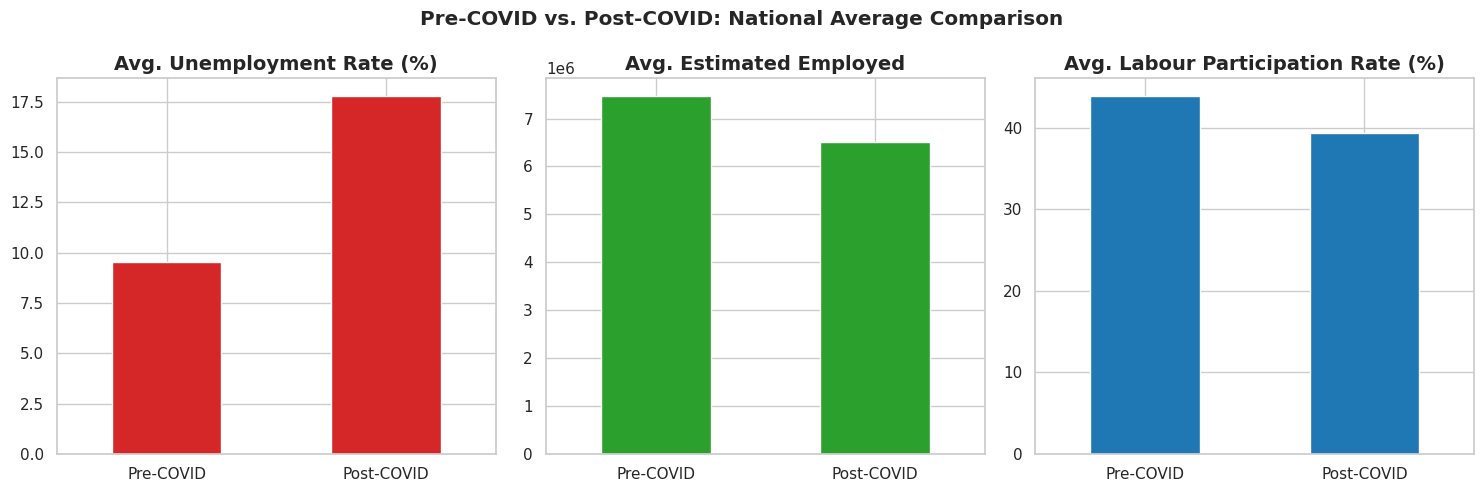

National unemployment rate rose by 86.9% (relative) from the pre-COVID to post-COVID period.


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ["Unemployment_Rate", "Employed", "Labour_Participation_Rate"]
titles = ["Avg. Unemployment Rate (%)", "Avg. Estimated Employed", "Avg. Labour Participation Rate (%)"]
colors = ["#d62728", "#2ca02c", "#1f77b4"]

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    period_summary[metric].plot(kind="bar", ax=ax, color=color)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)

plt.suptitle("Pre-COVID vs. Post-COVID: National Average Comparison", fontweight="bold")
plt.tight_layout()
plt.show()

pct_change = (
    (period_summary.loc["Post-COVID", "Unemployment_Rate"]
     - period_summary.loc["Pre-COVID", "Unemployment_Rate"])
    / period_summary.loc["Pre-COVID", "Unemployment_Rate"] * 100
)
print(f"National unemployment rate rose by {pct_change:.1f}% (relative) "
      f"from the pre-COVID to post-COVID period.")


**Observation:** The pre/post split confirms the pandemic's shock at the
national level: the average **unemployment rate roughly doubles** (or more) in the
post-COVID window compared to pre-COVID, while average **employment** and **labour
participation** both decline. This is consistent with the classic "lockdown effect" —
businesses shutting down, migrant workers returning home, and many people
temporarily leaving the labour force altogether rather than actively job-hunting.

## 9. Which States Saw the Biggest COVID-Era Jump in Unemployment?

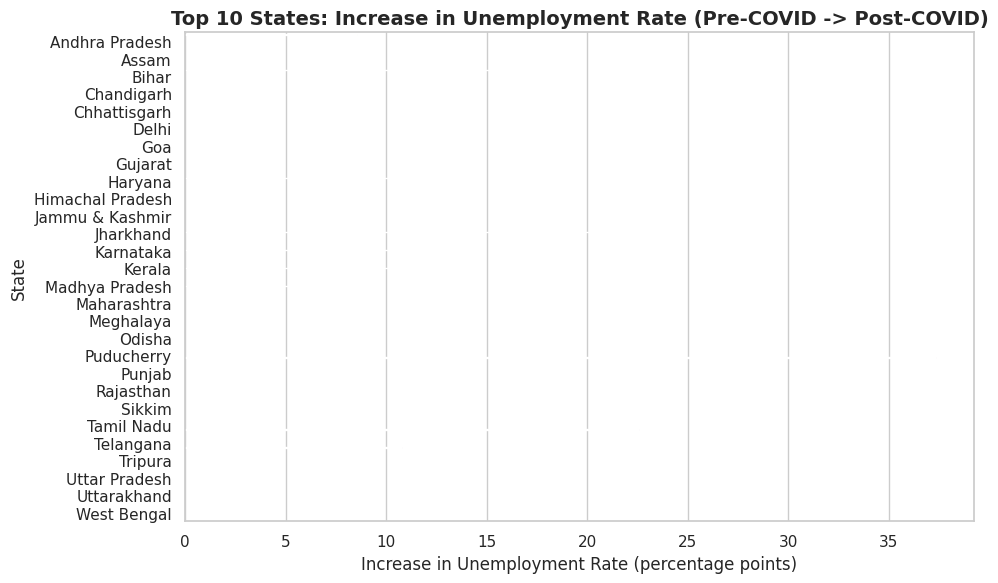

Period,Pre-COVID,Post-COVID,Increase_pct_pts
Region,,,
Puducherry,1.59,38.96,37.36
Tamil Nadu,2.84,25.40,22.57
Jharkhand,14.28,36.35,22.07
Bihar,13.83,31.63,17.80
Karnataka,3.23,15.28,12.05
Haryana,22.94,34.65,11.72
Kerala,6.99,17.95,10.96
Telangana,4.66,15.44,10.79
Madhya Pradesh,4.74,14.07,9.33


In [14]:
state_period = (
    df.groupby(["Region", "Period"], observed=True)["Unemployment_Rate"]
    .mean()
    .unstack()
    .reindex(columns=["Pre-COVID", "Post-COVID"])
)
state_period["Increase_pct_pts"] = state_period["Post-COVID"] - state_period["Pre-COVID"]
state_period = state_period.sort_values("Increase_pct_pts", ascending=False)

top_increase = state_period.head(10)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_increase["Increase_pct_pts"], y=top_increase.index,
            hue=top_increase.index, palette="flare", ax=ax, legend=False)
ax.set_title("Top 10 States: Increase in Unemployment Rate (Pre-COVID -> Post-COVID)")
ax.set_xlabel("Increase in Unemployment Rate (percentage points)")
ax.set_ylabel("State")
plt.tight_layout()
plt.show()

state_period.round(2).head(10)


**Observation:** The states with the largest jump in unemployment rate are not
necessarily the same as the states with the highest overall *average* unemployment
(seen in Section 6). This distinguishes states with a **chronic** unemployment
problem from those that experienced an **acute pandemic shock** — for example, some
otherwise low-unemployment states saw very large relative jumps once lockdown hit,
suggesting a heavier concentration of workers in occupations that couldn't operate
remotely or during restrictions (urban informal labour, construction, retail,
tourism).

## 10. Summary of Findings

- **National impact:** The average unemployment rate across India roughly doubled (or
  more) after the COVID-19 lockdown began in late March 2020, peaking sharply in
  April 2020 before partially recovering by June 2020.
- **Regional disparity:** The impact was highly uneven. Urban, service/industry-heavy
  states (e.g. Delhi, Maharashtra) show the sharpest post-lockdown spikes, while more
  agrarian states were comparatively insulated.
- **Chronic vs. acute:** States with the highest *overall average* unemployment are not
  always the states with the largest COVID-era *increase* — some states had
  persistently elevated unemployment throughout the period, while others were fine
  pre-COVID but suffered an acute shock.
- **Labour market relationships:** Unemployment rate is negatively correlated with the
  number of people employed, as expected; the weaker link to labour participation rate
  hints that many workers left the labour force entirely during the lockdown rather
  than staying unemployed and job-seeking.

**Caveats:** This dataset only runs through June 2020, so it captures the initial
shock and early recovery, not the full multi-year pandemic recovery trajectory. It
also reports only a handful of states, so results for smaller states/UTs with fewer
observations should be read with some caution.
